Linear Regression Errors:
Mean Absolute Error: 3704.062464775676
Mean Squared Error: 1324526383.844562
Root Mean Squared Error: 36394.043246725996

SVR Errors:
Mean Absolute Error: 1737.502751203738
Mean Squared Error: 1326775196.3982723
Root Mean Squared Error: 36424.92548239834

Decision Tree Errors:
Mean Absolute Error: 3539.007513661202
Mean Squared Error: 2853861834.883197
Root Mean Squared Error: 53421.54841338088

Random Forest Errors:
Mean Absolute Error: 3436.41860112299
Mean Squared Error: 1184272351.3312044
Root Mean Squared Error: 34413.25836550797


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



ANN Errors:
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Mean Absolute Error: 3344.38671875
Mean Squared Error: 1322318848.0
Root Mean Squared Error: 36363.702341758326

Final evaluation on Test Set using ANN:
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
Mean Absolute Error: 6724.91259765625
Mean Squared Error: 20451074048.0
Root Mean Squared Error: 143007.25173221112


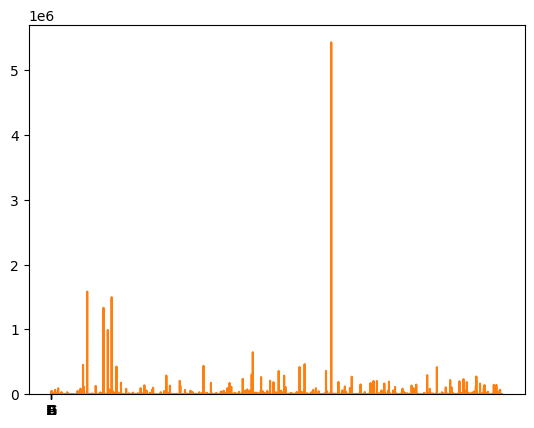

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn import linear_model
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import keras
from keras.layers import Dense
import joblib

data_train = pd.read_csv("/home/train (1).csv")

plt.hist(data_train["category"])
plt.savefig("category_distribution.png")

plt.plot(data_train["adview"])
plt.savefig("adview_plot.png")

data_train = data_train[data_train.views != 'F']
data_train = data_train[data_train.likes != 'F']
data_train = data_train[data_train.dislikes != 'F']
data_train = data_train[data_train.comment != 'F']

category = {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7, 'H': 8}
data_train["category"] = data_train["category"].map(category)

data_train["views"] = pd.to_numeric(data_train["views"])
data_train["comment"] = pd.to_numeric(data_train["comment"])
data_train["likes"] = pd.to_numeric(data_train["likes"])
data_train["dislikes"] = pd.to_numeric(data_train["dislikes"])
data_train["adview"] = pd.to_numeric(data_train["adview"])

data_train['vidid'] = LabelEncoder().fit_transform(data_train['vidid'])
data_train['published'] = LabelEncoder().fit_transform(data_train['published'])

def time_to_sec(x):
    y = x[2:]
    h, m, s = '', '', ''
    mm = ''
    for i in y:
        if i not in ['H', 'M', 'S']:
            mm += i
        else:
            if i == "H":
                h = mm
                mm = ''
            elif i == "M":
                m = mm
                mm = ''
            else:
                s = mm
                mm = ''
    h = h if h != '' else '0'
    m = m if m != '' else '0'
    s = s if s != '' else '0'
    return int(h) * 3600 + int(m) * 60 + int(s)

data_train["duration"] = data_train["duration"].apply(time_to_sec)

Y_train = data_train["adview"]
X_train = data_train.drop(["adview", "vidid"], axis=1)

X_train, X_temp, y_train, y_temp = train_test_split(X_train, Y_train, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

def print_error(X, y, model):
    prediction = model.predict(X)
    print('Mean Absolute Error:', metrics.mean_absolute_error(y, prediction))
    print('Mean Squared Error:', metrics.mean_squared_error(y, prediction))
    print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y, prediction)))

lr = linear_model.LinearRegression()
lr.fit(X_train, y_train)
print("Linear Regression Errors:")
print_error(X_val, y_val, lr)

svr = SVR()
svr.fit(X_train, y_train.values.ravel())
print("\nSVR Errors:")
print_error(X_val, y_val, svr)

dt = DecisionTreeRegressor()
dt.fit(X_train, y_train)
print("\nDecision Tree Errors:")
print_error(X_val, y_val, dt)

rf = RandomForestRegressor(n_estimators=200, max_depth=25, min_samples_split=15)
rf.fit(X_train, y_train.values.ravel())
print("\nRandom Forest Errors:")
print_error(X_val, y_val, rf)

ann = keras.models.Sequential([
    Dense(6, activation="relu", input_shape=(X_train.shape[1],)),
    Dense(6, activation="relu"),
    Dense(1)
])
ann.compile(optimizer='adam', loss='mean_squared_error', metrics=["mean_squared_error"])
ann.fit(X_train, y_train, epochs=100, verbose=0)
print("\nANN Errors:")
print_error(X_val, y_val, ann)

joblib.dump(rf, "best_model_rf.pkl")
ann.save("best_model_ann.keras")
joblib.dump(scaler, "scaler.pkl")

print("\nFinal evaluation on Test Set using ANN:")
print_error(X_test, y_test, ann)